# Notebook 14b — MJO Supervised 2D Encoder (lat-aware, 16 × 180)
**Project:** ENSO-BSISO SSL — MJO Extension  
**Author:** Jiayi (jh9141@nyu.edu)

Variant of `nb14` using the **lat-aware preprocessing** from `nb13b`. Input shape `(N, 3, 16, 180)` — the 15°S–15°N latitude strip is preserved end-to-end.

**Session 28 rewrite.** The first attempt (Session 25 architecture, with widening 3→16→32→32→32 in the lat stage and frozen 32→32→32 in the lon stage) collapsed to a 1D line in embedding space (see Session 27). Root cause: lon-feature-widening capacity was lost during the lat-aware rewrite, leaving the encoder structurally biased toward seasonal pattern (lat axis) and away from MJO phase (lon axis).

**Corrected design (Session 28):** treat nb14 as a black box and prepend a **constant-3-channel lat-compression prefix**. The lon pipeline, head, and Linear projection are byte-for-byte identical to nb14. If the lat prefix learns near-uniform weights, the network falls back to nb14 behavior — graceful fallback property preserved.

## Setup (locked decisions)

| Knob | Value | Source |
|---|---|---|
| Input | `X_MJO_lat16.npy`, shape `(N, 3, 16, 180)` | nb13b |
| Channel order | `[u850, OLR, u200]` | nb13b |
| Embedding dim | 2 (no L2 norm) | Phase 1 lesson from BSISO |
| Loss | raw dot product InfoNCE | nb07c |
| Temperature τ | 0.5 | nb07c |
| Weight decay | 1e-4 | nb07c |
| Optimizer | Adam, lr=1e-3, cosine→1e-5 | nb07c |
| Epochs | 50 | nb07c |
| Architecture | Constant-3-channel lat prefix (k=3×3, 4 blocks) + nb14-identical lon pipeline (k=1×3, 3 blocks) | **Session 28 rewrite** |
| Bandpass on input | **none** | Session 25 (sup uses labels as the intraseasonal anchor) |
| Active MJO filter | amplitude ≥ 1.0 AND phase ∈ [1,8] | RMM convention |
| Year split | every 5th year held out | nb04/nb07c |

## Outputs

- `MJO/lat16/checkpoints/encoder_mjo_sup_lat16_final.pth`
- `MJO/lat16/checkpoints/training_history_mjo_sup_lat16.json`
- `MJO/lat16/results/sup/embeddings.npy`, `training_curves.png`, `embedding_2d_overview.png`, `radius_diagnostics.png`, `linear_probe_results.json`, `enso_displacement.png`, `mjo_sup_lat16_summary.md`

## Runtime
~30–45 min on T4. Total params ≈ 5.3 K (down from the failed Session 25 design's 30 K; closer to nb14's ~7 K).

---

## Cell 1 — Mount Drive + Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt

EMBEDDING_DIM = 2
RUN_TAG       = 'mjo_sup_lat16'
TEMPERATURE   = 0.5
EPOCHS        = 50
BATCH_SIZE    = 64
LR            = 1e-3
WEIGHT_DECAY  = 1e-4

PROJECT_DIR    = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR        = f'{PROJECT_DIR}/MJO'
LAT16_DIR      = f'{MJO_DIR}/lat16'
PROCESSED_DIR  = f'{LAT16_DIR}/data/processed'
CHECKPOINT_DIR = f'{LAT16_DIR}/checkpoints'
RESULTS_DIR    = f'{LAT16_DIR}/results/sup'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_FILE      = 'X_MJO_lat16.npy'
LABELS_FILE = 'labels_aligned_mjo_lat16.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:        {device}')
print(f'Embedding dim: {EMBEDDING_DIM} (no L2 normalization)')
print(f'Loss:          raw dot product InfoNCE (τ={TEMPERATURE})')
print(f'Run tag:       {RUN_TAG}')
print(f'Results dir:   MJO/lat16/results/sup/')

Mounted at /content/drive
Device:        cpu
Embedding dim: 2 (no L2 normalization)
Loss:          raw dot product InfoNCE (τ=0.5)
Run tag:       mjo_sup_lat16
Results dir:   MJO/lat16/results/sup/


## Cell 2 — Load Data + Year-Based Split + Active MJO Filter

Build `phase_enso_index` only over **train days that are active MJO** (amplitude ≥ 1.0 AND phase ∈ {1,...,8}). Weak/inactive MJO days are kept in X but never sampled into positive/hard-negative pairs.

In [2]:
X      = np.load(f'{PROCESSED_DIR}/{X_FILE}')
labels = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_FILE}', parse_dates=['date'])

print(f'X shape:  {X.shape}  (N, channels, lat, lon)')
print(f'Labels:   {len(labels)} rows')
assert X.shape[0] == len(labels), 'X / labels length mismatch!'
assert X.shape[1:] == (3, 16, 180), f'Unexpected X shape: {X.shape[1:]}; expected (3, 16, 180).'

# Year-based split: every 5th year held out
all_years = sorted(labels['date'].dt.year.unique())
val_years = all_years[::5]
train_years = [y for y in all_years if y not in val_years]
year_col  = labels['date'].dt.year
train_idx = labels.index[year_col.isin(train_years)].values
val_idx   = labels.index[year_col.isin(val_years)].values

print(f'\nVal years ({len(val_years)}): {val_years}')
print(f'Train: {len(train_idx)} samples ({100*len(train_idx)/len(labels):.1f}%)')
print(f'Val:   {len(val_idx)} samples ({100*len(val_idx)/len(labels):.1f}%)')

# Build (phase, ENSO) → indices ONLY from active MJO days in the train set
phase_enso_index = defaultdict(list)
for idx in train_idx:
    row = labels.loc[idx]
    if (not row['weak_mjo']) and (1 <= row['phase'] <= 8):
        key = (int(row['phase']), row['enso_category'])
        phase_enso_index[key].append(idx)

active_total = sum(len(v) for v in phase_enso_index.values())
print(f'\nActive MJO train days (ampl ≥ 1.0, phase 1-8): {active_total} / {len(train_idx)}')
print(f'\n(phase × ENSO) bin sizes:')
for ph in range(1, 9):
    counts = [len(phase_enso_index[(ph, c)]) for c in ['El Nino', 'Neutral', 'La Nina']]
    print(f'  P{ph}:  EN={counts[0]:4d}  Neu={counts[1]:4d}  LN={counts[2]:4d}')

X shape:  (16436, 3, 16, 180)  (N, channels, lat, lon)
Labels:   16436 rows

Val years (9): [np.int32(1979), np.int32(1984), np.int32(1989), np.int32(1994), np.int32(1999), np.int32(2004), np.int32(2009), np.int32(2014), np.int32(2019)]
Train: 13149 samples (80.0%)
Val:   3287 samples (20.0%)

Active MJO train days (ampl ≥ 1.0, phase 1-8): 8029 / 13149

(phase × ENSO) bin sizes:
  P1:  EN= 232  Neu= 543  LN= 279
  P2:  EN= 269  Neu= 524  LN= 323
  P3:  EN= 311  Neu= 379  LN= 294
  P4:  EN= 257  Neu= 386  LN= 315
  P5:  EN= 219  Neu= 459  LN= 398
  P6:  EN= 191  Neu= 422  LN= 404
  P7:  EN= 188  Neu= 396  LN= 393
  P8:  EN= 205  Neu= 377  LN= 265


## Cell 3 — PairSampler + Dataset + DataLoaders

Same logic as nb14. The pair construction is independent of input shape — it operates on label indices.

In [3]:
class PairSampler:
    def __init__(self, labels_df, phase_enso_index):
        self.labels = labels_df
        self.index  = phase_enso_index
        self.enso_categories = labels_df['enso_category'].unique().tolist()

    def sample_positive_pair(self):
        key = self._random_category()
        indices = self.index[key]
        if len(indices) < 2:
            return self.sample_easy_negative_pair()
        idx_A, idx_B = np.random.choice(indices, size=2, replace=False)
        year_A = self.labels.loc[idx_A, 'date'].year
        other = [i for i in indices if self.labels.loc[i, 'date'].year != year_A]
        if other:
            idx_B = np.random.choice(other)
        return idx_A, idx_B, 'positive'

    def sample_hard_negative_pair(self):
        if len(self.enso_categories) < 2:
            return self.sample_easy_negative_pair()
        phase = np.random.choice(range(1, 9))
        enso_A, enso_B = np.random.choice(self.enso_categories, size=2, replace=False)
        key_A, key_B = (phase, enso_A), (phase, enso_B)
        if not self.index[key_A] or not self.index[key_B]:
            return self.sample_positive_pair()
        idx_A = np.random.choice(self.index[key_A])
        idx_B = np.random.choice(self.index[key_B])
        return idx_A, idx_B, 'hard_negative'

    def sample_easy_negative_pair(self):
        phase_A, phase_B = np.random.choice(range(1, 9), size=2, replace=False)
        enso_A = np.random.choice(self.enso_categories)
        enso_B = np.random.choice(self.enso_categories)
        key_A, key_B = (phase_A, enso_A), (phase_B, enso_B)
        idx_A = (np.random.choice(self.index[key_A]) if self.index[key_A]
                 else self.labels[self.labels['phase'] == phase_A].sample(1).index[0])
        idx_B = (np.random.choice(self.index[key_B]) if self.index[key_B]
                 else self.labels[self.labels['phase'] == phase_B].sample(1).index[0])
        return idx_A, idx_B, 'easy_negative'

    def _random_category(self):
        valid = [k for k in self.index if len(self.index[k]) > 0]
        return valid[np.random.randint(len(valid))]


class MJOPairDataset(Dataset):
    def __init__(self, X_data, labels_df, phase_enso_index,
                 mode='train', train_indices=None):
        self.X       = X_data
        self.labels  = labels_df
        self.sampler = PairSampler(labels_df, phase_enso_index)
        self.mode    = mode
        self.train_indices = (train_indices if train_indices is not None
                              else np.arange(len(X_data)))
        if mode == 'val':
            self.val_pairs = self._create_val_pairs()

    def _create_val_pairs(self):
        pairs = []
        val_labels = self.labels.loc[self.train_indices]
        for phase in range(1, 9):
            for enso in self.sampler.enso_categories:
                group = val_labels[
                    (val_labels['phase'] == phase) &
                    (val_labels['enso_category'] == enso) &
                    (~val_labels['weak_mjo'])
                ].index.tolist()
                for i in range(len(group)):
                    for j in range(i + 1, len(group)):
                        pairs.append((group[i], group[j], 'positive'))
        return pairs[:1000]

    def __len__(self):
        return (len(self.train_indices) if self.mode == 'train'
                else len(self.val_pairs))

    def __getitem__(self, idx):
        if self.mode == 'train':
            r = np.random.rand()
            if r < 0.30:
                idx_A, idx_B, _ = self.sampler.sample_positive_pair()
            elif r < 0.50:
                idx_A, idx_B, _ = self.sampler.sample_hard_negative_pair()
            else:
                idx_A, idx_B, _ = self.sampler.sample_easy_negative_pair()
        else:
            idx_A, idx_B, _ = self.val_pairs[idx]
        field_A = torch.from_numpy(self.X[idx_A]).float()
        field_B = torch.from_numpy(self.X[idx_B]).float()
        return field_A, field_B


train_dataset = MJOPairDataset(X, labels, phase_enso_index, mode='train', train_indices=train_idx)
val_dataset   = MJOPairDataset(X, labels, phase_enso_index, mode='val',   train_indices=val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train dataset: {len(train_dataset)} items  →  {len(train_loader)} batches/epoch')
print(f'Val dataset:   {len(val_dataset)} pairs   →  {len(val_loader)} batches')

Train dataset: 13149 items  →  206 batches/epoch
Val dataset:   1000 pairs   →  16 batches


## Cell 4 — Lat-Aware CNN Encoder for `(N, 3, 16, 180)`  *(Session 28 rewrite)*

**Design principle:** preserve nb14's lon pipeline *byte-for-byte* and prepend a **constant-3-channel lat-compression prefix**. If the lat prefix learns weights close to uniform meridional averaging, the network falls back to nb14 behavior. The first attempt (Session 25) widened channels to 32 inside the lat stage and froze them at 32 throughout the lon stage; that broke nb14's `3→16→32→32` lon feature hierarchy and the encoder collapsed to a 1D line (Session 27 diagnosis).

```
Input: (B, 3, 16, 180)

Lat-compression prefix — 4 blocks, constant 3 channels, k=(3,3), lat-only pool:
  Block 1: Conv2d(3→3) → BN → ReLU → MaxPool((2,1))   # (3,16,180) → (3, 8,180)
  Block 2: Conv2d(3→3) → BN → ReLU → MaxPool((2,1))   # (3, 4,180)
  Block 3: Conv2d(3→3) → BN → ReLU → MaxPool((2,1))   # (3, 2,180)
  Block 4: Conv2d(3→3) → BN → ReLU → MaxPool((2,1))   # (3, 1,180)

Lon pipeline — IDENTICAL to nb14 (3 blocks, k=(1,3), lon-only pool):
  Block 5: Conv2d(3→16) → BN → ReLU → MaxPool((1,2))   # (16,1, 90)
  Block 6: Conv2d(16→32) → BN → ReLU → MaxPool((1,2))  # (32,1, 45)
  Block 7: Conv2d(32→32) → BN → ReLU                   # (32,1, 45), no pool

Head (matches nb14):
  AdaptiveAvgPool2d(1) → Flatten → Linear(32, 2)  # no L2 norm
```

Total params ≈ **5.3 K** (lat prefix ≈ 0.35 K, lon pipeline ≈ 4.9 K, head ≈ 0.07 K). Closer to nb14's ~7 K than the failed Session 25 design's 30 K.

In [4]:
class MJOEncoderNoL2Lat16(nn.Module):
    """Lat-aware encoder for (B, 3, 16, 180).

    Design: a constant-3-channel lat-compression prefix (4 blocks of 3x3 conv
    with lat-only pool collapsing 16->1) feeds into nb14's lon pipeline
    byte-for-byte (3->16->32->32 with lon-only pool 180->90->45).

    Session 28 rewrite. The previous Session 25 architecture widened channels
    to 32 inside the lat stage and froze them at 32 across the lon stage,
    which broke nb14's lon feature hierarchy and collapsed the embedding to
    a 1D line. This rewrite preserves the working lon pipeline and uses the
    lat stage only as a learnable replacement for uniform meridional average.
    """
    def __init__(self, embedding_dim=2):
        super().__init__()
        # ---- Lat-compression prefix (constant 3 channels, 4 blocks) ----
        self.lat1_conv = nn.Conv2d(3, 3, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.lat1_bn   = nn.BatchNorm2d(3)
        self.lat1_pool = nn.MaxPool2d((2, 1))
        self.lat2_conv = nn.Conv2d(3, 3, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.lat2_bn   = nn.BatchNorm2d(3)
        self.lat2_pool = nn.MaxPool2d((2, 1))
        self.lat3_conv = nn.Conv2d(3, 3, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.lat3_bn   = nn.BatchNorm2d(3)
        self.lat3_pool = nn.MaxPool2d((2, 1))
        self.lat4_conv = nn.Conv2d(3, 3, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.lat4_bn   = nn.BatchNorm2d(3)
        self.lat4_pool = nn.MaxPool2d((2, 1))
        # ---- Lon pipeline (IDENTICAL to nb14) ----
        self.conv1 = nn.Conv2d(3,  16, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d((1, 2))
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d((1, 2))
        self.conv3 = nn.Conv2d(32, 32, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn3   = nn.BatchNorm2d(32)
        # ---- Head (matches nb14) ----
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc          = nn.Linear(32, embedding_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Lat prefix (16 -> 1 in lat)
        x = self.lat1_pool(F.relu(self.lat1_bn(self.lat1_conv(x))))
        x = self.lat2_pool(F.relu(self.lat2_bn(self.lat2_conv(x))))
        x = self.lat3_pool(F.relu(self.lat3_bn(self.lat3_conv(x))))
        x = self.lat4_pool(F.relu(self.lat4_bn(self.lat4_conv(x))))
        # nb14 lon pipeline (180 -> 90 -> 45)
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        # Head
        x = self.global_pool(x).view(x.size(0), -1)
        return self.fc(x)   # no L2 normalization


def InfoNCE_loss_raw(z_A, z_B, temperature):
    sim_matrix = torch.matmul(z_A, z_B.T) / temperature
    labels_ = torch.arange(z_A.size(0), device=z_A.device)
    return F.cross_entropy(sim_matrix, labels_)


# Sanity check — trace shapes through every stage
enc_test = MJOEncoderNoL2Lat16(embedding_dim=EMBEDDING_DIM)
total_params = sum(p.numel() for p in enc_test.parameters())
dummy = torch.randn(4, 3, 16, 180)

with torch.no_grad():
    x = dummy
    print(f'Input:                          {tuple(x.shape)}')
    x = enc_test.lat1_pool(F.relu(enc_test.lat1_bn(enc_test.lat1_conv(x))))
    print(f'Lat 1 (3 ch, lat pool):         {tuple(x.shape)}  (expect (4,3,8,180))')
    x = enc_test.lat2_pool(F.relu(enc_test.lat2_bn(enc_test.lat2_conv(x))))
    print(f'Lat 2 (3 ch, lat pool):         {tuple(x.shape)}  (expect (4,3,4,180))')
    x = enc_test.lat3_pool(F.relu(enc_test.lat3_bn(enc_test.lat3_conv(x))))
    print(f'Lat 3 (3 ch, lat pool):         {tuple(x.shape)}  (expect (4,3,2,180))')
    x = enc_test.lat4_pool(F.relu(enc_test.lat4_bn(enc_test.lat4_conv(x))))
    print(f'Lat 4 (3 ch, lat collapsed):    {tuple(x.shape)}  (expect (4,3,1,180))')
    x = enc_test.pool1(F.relu(enc_test.bn1(enc_test.conv1(x))))
    print(f'Lon 1 (3->16, lon pool):        {tuple(x.shape)}  (expect (4,16,1,90))')
    x = enc_test.pool2(F.relu(enc_test.bn2(enc_test.conv2(x))))
    print(f'Lon 2 (16->32, lon pool):       {tuple(x.shape)}  (expect (4,32,1,45))')
    x = F.relu(enc_test.bn3(enc_test.conv3(x)))
    print(f'Lon 3 (32->32, no pool):        {tuple(x.shape)}  (expect (4,32,1,45))')
    x = enc_test.global_pool(x).view(x.size(0), -1)
    print(f'After global pool + flatten:    {tuple(x.shape)}  (expect (4,32))')
    z = enc_test.fc(x)
    print(f'Output embedding:               {tuple(z.shape)}  (expect (4,2))')

out = enc_test(dummy)
print(f'\nTotal parameters: {total_params:,}  (expect ~5,300)')
print(f'Output shape: {out.shape}  (expect [4, {EMBEDDING_DIM}])')
print(f'Init norms:   {out.norm(dim=1).detach().numpy()}')

Input:                          (4, 3, 16, 180)
Lat 1 (3 ch, lat pool):         (4, 3, 8, 180)  (expect (4,3,8,180))
Lat 2 (3 ch, lat pool):         (4, 3, 4, 180)  (expect (4,3,4,180))
Lat 3 (3 ch, lat pool):         (4, 3, 2, 180)  (expect (4,3,2,180))
Lat 4 (3 ch, lat collapsed):    (4, 3, 1, 180)  (expect (4,3,1,180))
Lon 1 (3->16, lon pool):        (4, 16, 1, 90)  (expect (4,16,1,90))
Lon 2 (16->32, lon pool):       (4, 32, 1, 45)  (expect (4,32,1,45))
Lon 3 (32->32, no pool):        (4, 32, 1, 45)  (expect (4,32,1,45))
After global pool + flatten:    (4, 32)  (expect (4,32))
Output embedding:               (4, 2)  (expect (4,2))

Total parameters: 5,326  (expect ~5,300)
Output shape: torch.Size([4, 2])  (expect [4, 2])
Init norms:   [0.0304791  0.04039602 0.02598601 0.04445251]


## Cell 5 — Initialize Model + Optimizer

In [5]:
encoder   = MJOEncoderNoL2Lat16(embedding_dim=EMBEDDING_DIM).to(device)
optimizer = optim.Adam(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f'Model on:    {device}')
print(f'Parameters:  {sum(p.numel() for p in encoder.parameters()):,}')
print(f'\nTraining config:')
print(f'  Epochs:        {EPOCHS}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Temperature:   {TEMPERATURE}')
print(f'  LR:            {LR} → 1e-5 (cosine)')
print(f'  Weight decay:  {WEIGHT_DECAY}')
print(f'  Train batches/epoch: {len(train_loader)}')

Model on:    cpu
Parameters:  5,326

Training config:
  Epochs:        50
  Batch size:    64
  Temperature:   0.5
  LR:            0.001 → 1e-5 (cosine)
  Weight decay:  0.0001
  Train batches/epoch: 206


## Cell 6 — Training Loop (with Norm Trajectory Tracking)

In [6]:
from tqdm.notebook import tqdm

history = {'train_loss': [], 'val_loss': [], 'epoch_time': [],
           'mean_norm': [], 'std_norm': [], 'max_norm': []}

for epoch in range(EPOCHS):
    t0 = time.time()
    encoder.train()
    train_loss = 0.0
    epoch_norms = []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)
    for fA, fB in pbar:
        fA = fA.to(device, non_blocking=True)
        fB = fB.to(device, non_blocking=True)
        zA = encoder(fA); zB = encoder(fB)
        with torch.no_grad():
            epoch_norms.extend(zA.norm(dim=1).cpu().numpy().tolist())
            epoch_norms.extend(zB.norm(dim=1).cpu().numpy().tolist())
        loss = InfoNCE_loss_raw(zA, zB, temperature=TEMPERATURE)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    train_loss /= len(train_loader)

    encoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for fA, fB in val_loader:
            fA = fA.to(device, non_blocking=True); fB = fB.to(device, non_blocking=True)
            zA = encoder(fA); zB = encoder(fB)
            val_loss += InfoNCE_loss_raw(zA, zB, temperature=TEMPERATURE).item()
    val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else float('nan')
    scheduler.step()

    en = np.array(epoch_norms); et = time.time() - t0
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['epoch_time'].append(et)
    history['mean_norm'].append(float(en.mean())); history['std_norm'].append(float(en.std()))
    history['max_norm'].append(float(en.max()))
    print(f'ep {epoch+1:2d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  '
          f'norm μ={en.mean():.3f} σ={en.std():.3f} max={en.max():.2f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}  time={et:.1f}s')

    if (epoch + 1) % 10 == 0:
        torch.save({'epoch': epoch+1, 'model_state_dict': encoder.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_loss': train_loss, 'val_loss': val_loss},
                   f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_epoch_{epoch+1}.pth')

torch.save(encoder.state_dict(), f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_final.pth')
with open(f'{CHECKPOINT_DIR}/training_history_{RUN_TAG}.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nTraining complete. Total time: {sum(history["epoch_time"])/60:.1f} min')
print(f'Best val loss: {min(history["val_loss"]):.4f}  (epoch {history["val_loss"].index(min(history["val_loss"]))+1})')
print(f'Final mean norm: {history["mean_norm"][-1]:.3f}  max norm: {history["max_norm"][-1]:.2f}')

Epoch 1/50:   0%|          | 0/206 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ep  1/50  train=4.1408  val=4.1370  norm μ=0.200 σ=0.181 max=1.41  lr=9.99e-04  time=46.7s


Epoch 2/50:   0%|          | 0/206 [00:00<?, ?it/s]

ep  2/50  train=4.1265  val=4.1396  norm μ=0.286 σ=0.196 max=1.29  lr=9.96e-04  time=46.5s


...

ep 48/50  train=4.0990  val=4.1602  norm μ=0.391 σ=0.181 max=1.10  lr=1.39e-05  time=46.2s


Epoch 49/50:   0%|          | 0/206 [00:00<?, ?it/s]

ep 49/50  train=4.1023  val=4.1578  norm μ=0.392 σ=0.183 max=1.15  lr=1.10e-05  time=46.2s


Epoch 50/50:   0%|          | 0/206 [00:00<?, ?it/s]

ep 50/50  train=4.1049  val=4.1556  norm μ=0.391 σ=0.182 max=1.12  lr=1.00e-05  time=46.1s

Training complete. Total time: 38.4 min
Best val loss: 4.1370  (epoch 1)
Final mean norm: 0.391  max norm: 1.12


## Cell 7 — Training Curves + Norm Trajectory

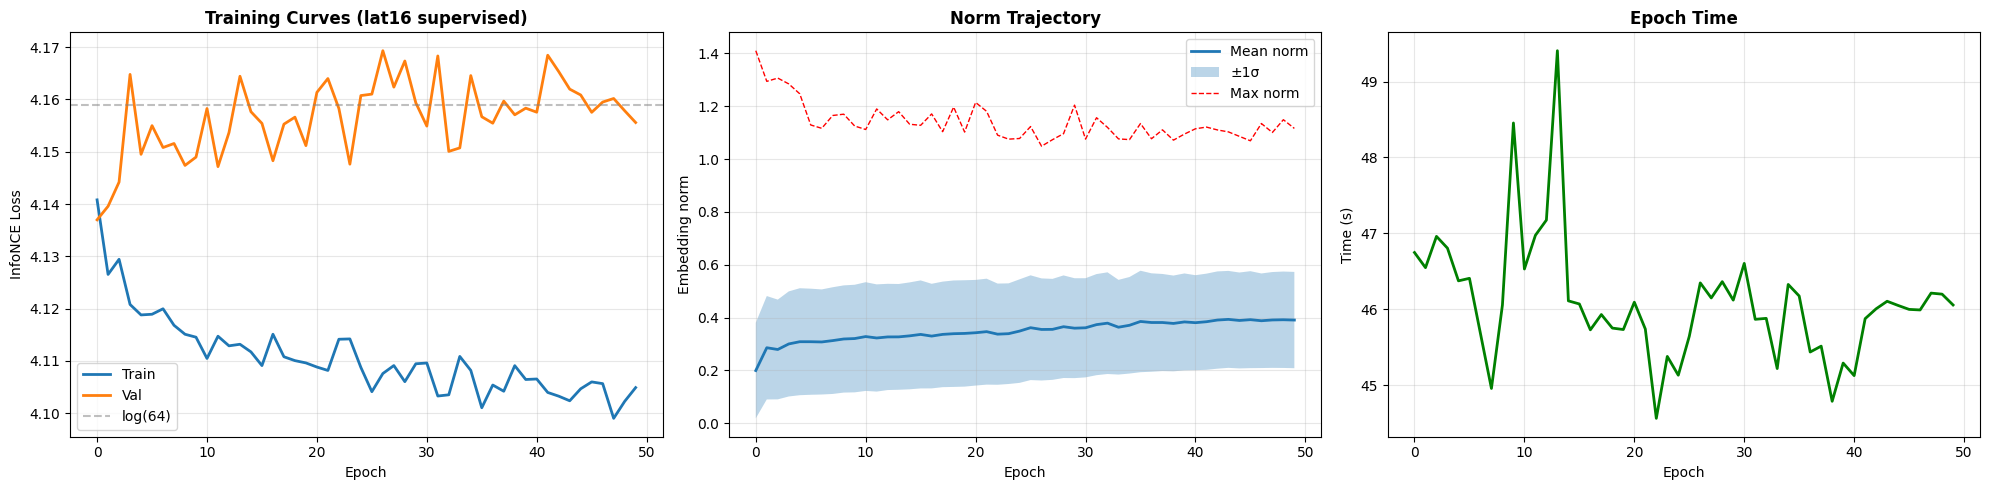


✓ Norms stable (max ever = 1.41)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].axhline(np.log(64), color='gray', linestyle='--', alpha=0.5, label='log(64)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('Training Curves (lat16 supervised)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['mean_norm'], label='Mean norm', linewidth=2)
axes[1].fill_between(range(len(history['mean_norm'])),
                     np.array(history['mean_norm']) - np.array(history['std_norm']),
                     np.array(history['mean_norm']) + np.array(history['std_norm']),
                     alpha=0.3, label='±1σ')
axes[1].plot(history['max_norm'], label='Max norm', color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Embedding norm')
axes[1].set_title('Norm Trajectory', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch_time'], color='green', linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Time (s)')
axes[2].set_title('Epoch Time', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

if max(history['max_norm']) > 100:
    print('\n⚠️  Norm explosion. Consider increasing WEIGHT_DECAY to 1e-3.')
else:
    print(f'\n✓ Norms stable (max ever = {max(history["max_norm"]):.2f})')

## Cell 8 — Extract Embeddings + 4-Panel Scatter

Embeddings shape: (16436, 2)
Norm:  min=0.114 max=1.204 mean=0.351 std=0.171
Angle: spread=2.929 rad


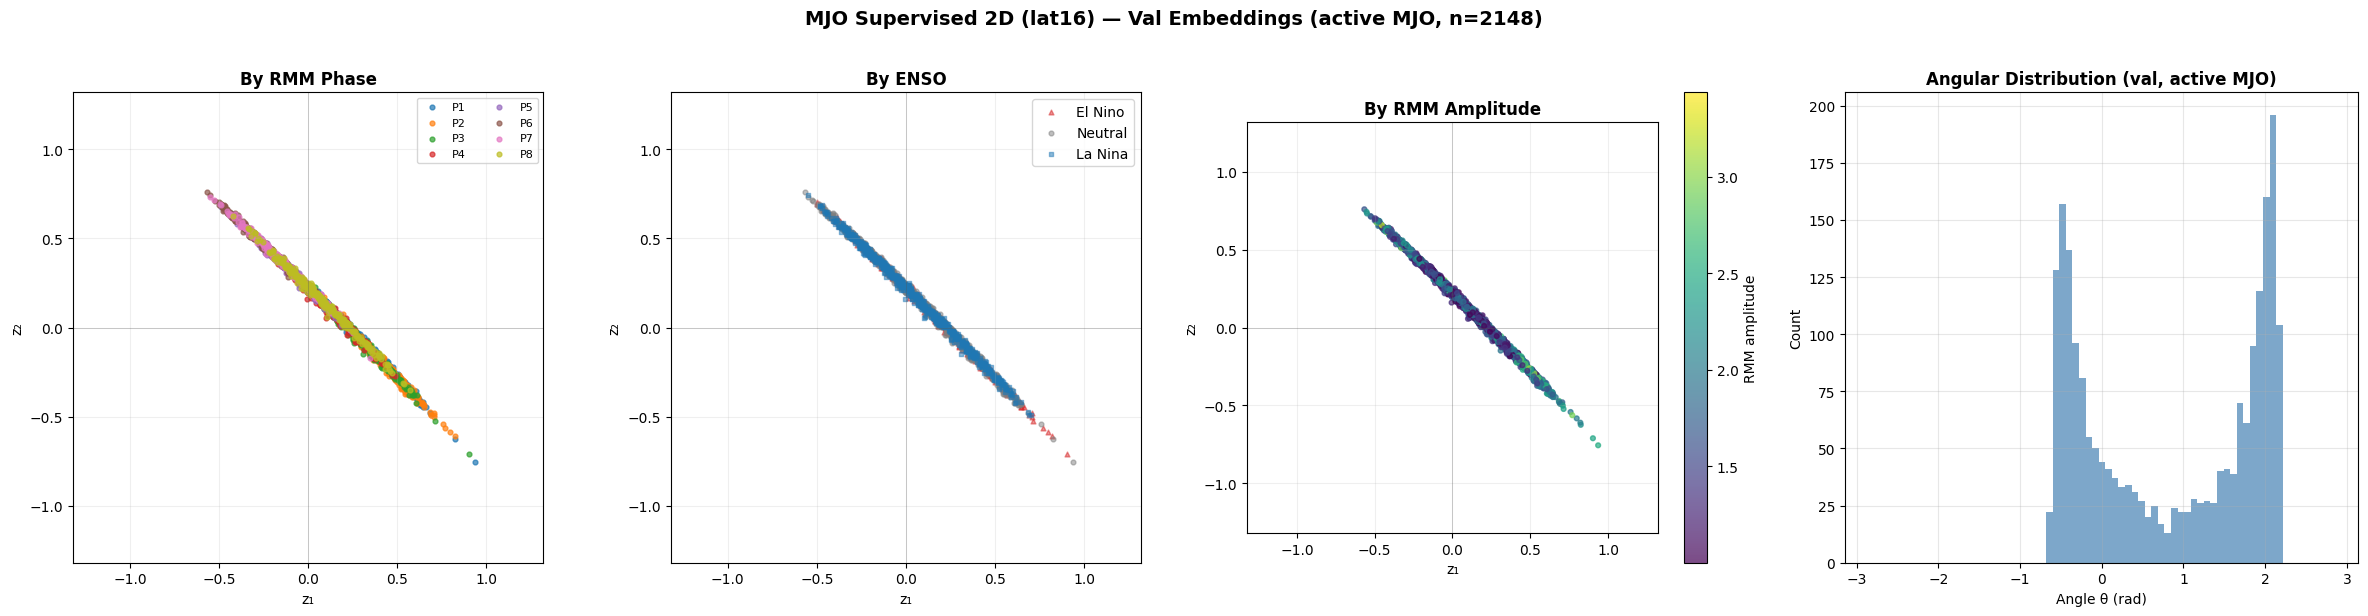

Saved: /content/drive/MyDrive/BSISO_SSL_Project/MJO/lat16/results/sup/embedding_2d_overview.png


In [8]:
encoder.eval()
embeddings_2d = np.zeros((len(X), EMBEDDING_DIM), dtype=np.float32)
with torch.no_grad():
    for start in range(0, len(X), 128):
        end = min(start + 128, len(X))
        batch = torch.from_numpy(X[start:end]).float().to(device)
        embeddings_2d[start:end] = encoder(batch).cpu().numpy()

np.save(f'{RESULTS_DIR}/embeddings.npy', embeddings_2d)

norms  = np.linalg.norm(embeddings_2d, axis=1)
angles = np.arctan2(embeddings_2d[:, 1], embeddings_2d[:, 0])
print(f'Embeddings shape: {embeddings_2d.shape}')
print(f'Norm:  min={norms.min():.3f} max={norms.max():.3f} mean={norms.mean():.3f} std={norms.std():.3f}')
print(f'Angle: spread={angles.max()-angles.min():.3f} rad')

# 4-panel scatter on val set (active MJO only for clarity)
lv = labels.loc[val_idx]
act_v = ~lv['weak_mjo'].values
Z_val = embeddings_2d[val_idx][act_v]
lv_a  = lv[act_v]

phase_colors = plt.cm.tab10(np.linspace(0, 0.8, 8))
enso_palette = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}
enso_marker  = {'El Nino': '^',       'Neutral': 'o',        'La Nina': 's'}

rng_lo = min(Z_val.min(), -1.1); rng_hi = max(Z_val.max(), 1.1)
pad = 0.1 * (rng_hi - rng_lo); rng_lo -= pad; rng_hi += pad

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# (a) by RMM phase
ax = axes[0]
for ph in range(1, 9):
    m = lv_a['phase'] == ph
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=[phase_colors[ph-1]], s=12, alpha=0.7, label=f'P{ph}')
ax.set_title('By RMM Phase', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.2)

# (b) by ENSO
ax = axes[1]
for cat in ['El Nino', 'Neutral', 'La Nina']:
    m = lv_a['enso_category'] == cat
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=enso_palette[cat], marker=enso_marker[cat], s=12, alpha=0.5, label=cat)
ax.set_title('By ENSO', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(); ax.grid(alpha=0.2)

# (c) by RMM amplitude
ax = axes[2]
sc = ax.scatter(Z_val[:, 0], Z_val[:, 1], c=lv_a['amplitude'].values,
                cmap='viridis', s=12, alpha=0.7)
ax.set_title('By RMM Amplitude', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
plt.colorbar(sc, ax=ax, label='RMM amplitude'); ax.grid(alpha=0.2)

# (d) angular histogram
ax = axes[3]
angles_val = np.arctan2(Z_val[:, 1], Z_val[:, 0])
ax.hist(angles_val, bins=36, color='steelblue', alpha=0.7)
ax.set_xlabel('Angle θ (rad)'); ax.set_ylabel('Count')
ax.set_title('Angular Distribution (val, active MJO)', fontweight='bold')
ax.set_xlim(-np.pi, np.pi); ax.grid(alpha=0.3)

plt.suptitle(f'MJO Supervised 2D (lat16) — Val Embeddings (active MJO, n={len(Z_val)})',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/embedding_2d_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/embedding_2d_overview.png')

## Cell 9 — Radius Diagnostics

Does the freed radius encode RMM amplitude (or anything systematic)?

Radius vs RMM amplitude (active MJO only):
  Pearson r  = 0.282  p = 9.51e-186
  Spearman r = 0.266  p = 2.96e-164

Radius by RMM phase (ANOVA): F=578.74  p=0.00e+00
Radius by ENSO (ANOVA):      F=26.93  p=2.16e-12


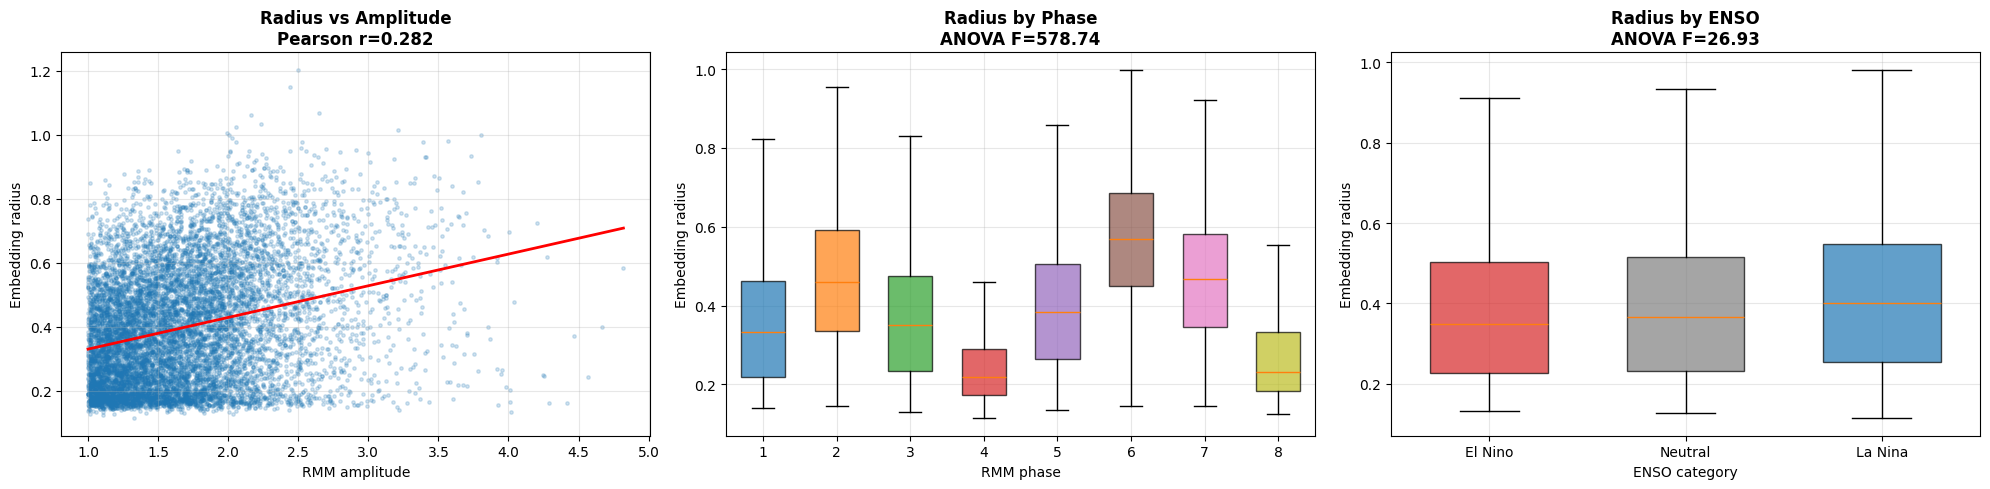

Saved: /content/drive/MyDrive/BSISO_SSL_Project/MJO/lat16/results/sup/radius_summary.json


In [9]:
from scipy.stats import pearsonr, spearmanr, f_oneway

active_mask = (~labels['weak_mjo'].values) & (labels['phase'].between(1, 8).values)
radii_a  = norms[active_mask]
ampl_a   = labels.loc[active_mask, 'amplitude'].values
phase_a  = labels.loc[active_mask, 'phase'].values
enso_a   = labels.loc[active_mask, 'enso_category'].values

r_p, p_p = pearsonr(radii_a, ampl_a)
r_s, p_s = spearmanr(radii_a, ampl_a)
print(f'Radius vs RMM amplitude (active MJO only):')
print(f'  Pearson r  = {r_p:.3f}  p = {p_p:.2e}')
print(f'  Spearman r = {r_s:.3f}  p = {p_s:.2e}')

radii_by_phase = [radii_a[phase_a == ph] for ph in range(1, 9)]
f_ph, p_ph = f_oneway(*radii_by_phase)
print(f'\nRadius by RMM phase (ANOVA): F={f_ph:.2f}  p={p_ph:.2e}')

radii_by_enso = {c: radii_a[enso_a == c] for c in ['El Nino', 'Neutral', 'La Nina']}
f_en, p_en = f_oneway(*radii_by_enso.values())
print(f'Radius by ENSO (ANOVA):      F={f_en:.2f}  p={p_en:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.scatter(ampl_a, radii_a, alpha=0.2, s=6)
ax.set_xlabel('RMM amplitude'); ax.set_ylabel('Embedding radius')
ax.set_title(f'Radius vs Amplitude\nPearson r={r_p:.3f}', fontweight='bold')
z_fit = np.polyfit(ampl_a, radii_a, 1)
x_fit = np.linspace(ampl_a.min(), ampl_a.max(), 100)
ax.plot(x_fit, np.polyval(z_fit, x_fit), 'r-', linewidth=2)
ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot(radii_by_phase, positions=range(1, 9), widths=0.6,
                patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], plt.cm.tab10(np.linspace(0, 0.8, 8))):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xlabel('RMM phase'); ax.set_ylabel('Embedding radius')
ax.set_title(f'Radius by Phase\nANOVA F={f_ph:.2f}', fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[2]
cats = ['El Nino', 'Neutral', 'La Nina']
bp = ax.boxplot([radii_by_enso[c] for c in cats], positions=[1, 2, 3], widths=0.6,
                patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], cats):
    patch.set_facecolor({'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}[c])
    patch.set_alpha(0.7)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(cats)
ax.set_xlabel('ENSO category'); ax.set_ylabel('Embedding radius')
ax.set_title(f'Radius by ENSO\nANOVA F={f_en:.2f}', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/radius_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

radius_summary = {
    'radius_vs_amplitude_pearson':  [float(r_p), float(p_p)],
    'radius_vs_amplitude_spearman': [float(r_s), float(p_s)],
    'radius_by_phase_anova': [float(f_ph), float(p_ph)],
    'radius_by_enso_anova':  [float(f_en), float(p_en)],
    'mean_radius': float(radii_a.mean()),
    'std_radius':  float(radii_a.std()),
}
with open(f'{RESULTS_DIR}/radius_summary.json', 'w') as f:
    json.dump(radius_summary, f, indent=2)
print(f'Saved: {RESULTS_DIR}/radius_summary.json')

## Cell 10 — Linear Probes (RMM Phase + ENSO Balanced)

Random baselines: 12.5% (8-phase) and 33.3% (3-class balanced).  
Probe only over **active MJO days** (consistent with how training pairs were defined).

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, GroupKFold

active_idx = np.where(active_mask)[0]
train_act  = np.intersect1d(train_idx, active_idx)
val_act    = np.intersect1d(val_idx,   active_idx)

Z_train = embeddings_2d[train_act]
Z_val_  = embeddings_2d[val_act]
gkf = GroupKFold(n_splits=5)
year_groups_act = labels.loc[active_idx, 'date'].dt.year.values

# RMM phase
y_tr = labels.loc[train_act, 'phase'].values
y_va = labels.loc[val_act,   'phase'].values
clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(Z_train, y_tr)
phase_val = float(accuracy_score(y_va, clf.predict(Z_val_)))
cv_phase = cross_val_score(clf, embeddings_2d[active_idx], labels.loc[active_idx, 'phase'].values,
                            cv=gkf, groups=year_groups_act, scoring='accuracy', n_jobs=-1)

# ENSO balanced
y_tr_e = labels.loc[train_act, 'enso_category'].values
y_va_e = labels.loc[val_act,   'enso_category'].values
clf_b = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
clf_b.fit(Z_train, y_tr_e)
enso_bal = float(balanced_accuracy_score(y_va_e, clf_b.predict(Z_val_)))
cv_enso = cross_val_score(clf_b, embeddings_2d[active_idx], labels.loc[active_idx, 'enso_category'].values,
                           cv=gkf, groups=year_groups_act, scoring='balanced_accuracy', n_jobs=-1)

probe_results = {
    'RMM Phase': {'val_acc': phase_val,  'cv_mean': float(cv_phase.mean()), 'cv_std': float(cv_phase.std())},
    'ENSO bal':  {'val_acc': enso_bal,   'cv_mean': float(cv_enso.mean()),  'cv_std': float(cv_enso.std())},
}

print('=' * 70)
print('MJO SUPERVISED LAT16 — LINEAR PROBE RESULTS')
print('=' * 70)
print(f'RMM phase val acc:    {phase_val*100:.1f}%  (random 12.5%)')
print(f'RMM phase 5-fold CV:  {cv_phase.mean()*100:.1f}% ± {cv_phase.std()*100:.1f}%')
print(f'ENSO  bal-acc val:    {enso_bal*100:.1f}%   (random 33.3%)')
print(f'ENSO  bal-acc CV:     {cv_enso.mean()*100:.1f}% ± {cv_enso.std()*100:.1f}%')
print(f'\nClassification report (RMM phase val):')
print(classification_report(y_va, clf.predict(Z_val_), zero_division=0))

with open(f'{RESULTS_DIR}/linear_probe_results.json', 'w') as f:
    json.dump(probe_results, f, indent=2)

MJO SUPERVISED LAT16 — LINEAR PROBE RESULTS
RMM phase val acc:    33.8%  (random 12.5%)
RMM phase 5-fold CV:  35.4% ± 1.5%
ENSO  bal-acc val:    37.8%   (random 33.3%)
ENSO  bal-acc CV:     36.0% ± 1.7%

Classification report (RMM phase val):
              precision    recall  f1-score   support

           1       0.33      0.32      0.33       343
           2       0.38      0.68      0.49       262
           3       0.43      0.04      0.07       222
           4       0.28      0.45      0.34       244
           5       0.24      0.45      0.32       233
           6       0.51      0.55      0.53       290
           7       0.30      0.07      0.11       275
           8       0.31      0.12      0.17       279

    accuracy                           0.34      2148
   macro avg       0.35      0.34      0.29      2148
weighted avg       0.35      0.34      0.30      2148



## Cell 11 — ENSO Displacement Z-Score

Same statistic as nb14 / BSISO nb07c. Computed over active MJO days only.

EN−LN displacement summary (MJO supervised, lat16):
  Observed mean: 0.0877
  Null baseline: 0.0127 ± 0.0032
  Z-score:       23.58
  (nb14 sup z=12.21;  BSISO sup z=2.53;  BSISO SSL z=14.55)


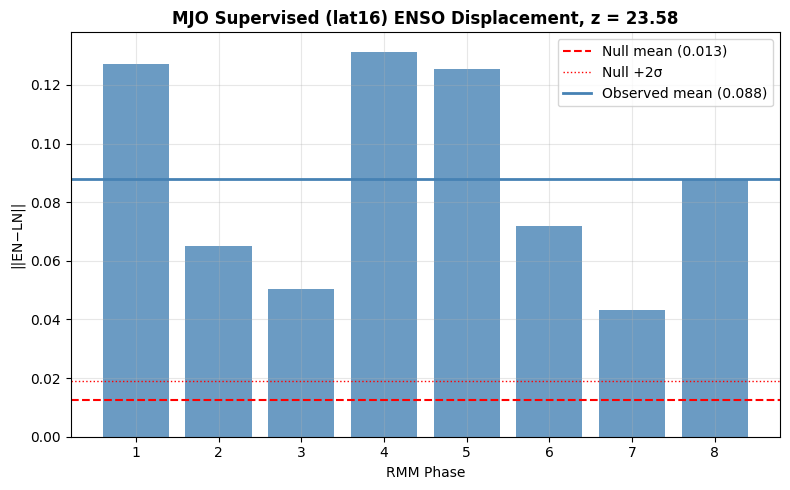

In [11]:
labels_act = labels.loc[active_mask].reset_index(drop=True)
emb_act = embeddings_2d[active_mask]

phases = range(1, 9)
disp_mag = []
for ph in phases:
    mEN = (labels_act['phase'] == ph) & (labels_act['enso_category'] == 'El Nino')
    mLN = (labels_act['phase'] == ph) & (labels_act['enso_category'] == 'La Nina')
    if mEN.sum() < 3 or mLN.sum() < 3:
        disp_mag.append(np.nan); continue
    cEN = emb_act[mEN].mean(axis=0); cLN = emb_act[mLN].mean(axis=0)
    disp_mag.append(np.linalg.norm(cEN - cLN))

rng = np.random.default_rng(42)
baseline_mag = []
for _ in range(100):
    shuf = labels_act['enso_category'].sample(frac=1, random_state=rng.integers(1e6)).values
    mtrl = []
    for ph in phases:
        mph = (labels_act['phase'] == ph).values
        mEN = mph & (shuf == 'El Nino'); mLN = mph & (shuf == 'La Nina')
        if mEN.sum() < 3 or mLN.sum() < 3: continue
        mtrl.append(np.linalg.norm(emb_act[mEN].mean(axis=0) - emb_act[mLN].mean(axis=0)))
    if mtrl: baseline_mag.append(np.mean(mtrl))

bmu = float(np.mean(baseline_mag)); bsd = float(np.std(baseline_mag))
obs_mu = float(np.nanmean(disp_mag))
z_score_sup = float((obs_mu - bmu) / (bsd + 1e-8))

print(f'EN−LN displacement summary (MJO supervised, lat16):')
print(f'  Observed mean: {obs_mu:.4f}')
print(f'  Null baseline: {bmu:.4f} ± {bsd:.4f}')
print(f'  Z-score:       {z_score_sup:.2f}')
print(f'  (nb14 sup z=12.21;  BSISO sup z=2.53;  BSISO SSL z=14.55)')

fig, ax = plt.subplots(figsize=(8, 5))
valid_p = [p for p, m in zip(phases, disp_mag) if not np.isnan(m)]
valid_m = [m for m in disp_mag if not np.isnan(m)]
ax.bar(valid_p, valid_m, color='steelblue', alpha=0.8)
ax.axhline(bmu, color='red', linestyle='--', linewidth=1.5, label=f'Null mean ({bmu:.3f})')
ax.axhline(bmu + 2*bsd, color='red', linestyle=':', linewidth=1, label='Null +2σ')
ax.axhline(obs_mu, color='steelblue', linewidth=2, label=f'Observed mean ({obs_mu:.3f})')
ax.set_xticks(range(1, 9))
ax.set_xlabel('RMM Phase'); ax.set_ylabel('||EN−LN||')
ax.set_title(f'MJO Supervised (lat16) ENSO Displacement, z = {z_score_sup:.2f}', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/enso_displacement.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Summary + Auto-Decision

In [12]:
import time as _t

# Reference numbers for context
NB14_SUP = {'phase_val': 0.577, 'phase_cv': '60.3% ± 1.7%', 'enso_bal': None, 'z': 12.21}
BSISO_SUP_2D = {'phase_val': 0.583, 'phase_cv': '65.7% ± 4.1%', 'enso_bal': 0.346, 'z': 2.53}
# Session 25 failed attempt for ablation context
NB14B_S25 = {'phase_val': 0.363, 'phase_cv': '40.1% ± 1.3%', 'enso_bal': 0.379, 'z': 19.82}

rows = [
    ['BSISO 2D supervised (nb07c)', f"{BSISO_SUP_2D['phase_val']*100:.1f}%", BSISO_SUP_2D['phase_cv'],
     f"{BSISO_SUP_2D['enso_bal']*100:.1f}%", f"{BSISO_SUP_2D['z']:.2f}"],
    ['MJO 2D supervised — meridional avg (nb14)', f"{NB14_SUP['phase_val']*100:.1f}%", NB14_SUP['phase_cv'],
     '—', f"{NB14_SUP['z']:.2f}"],
    ['MJO 2D supervised — lat16 Session 25 (failed; 1D collapse)', f"{NB14B_S25['phase_val']*100:.1f}%", NB14B_S25['phase_cv'],
     f"{NB14B_S25['enso_bal']*100:.1f}%", f"{NB14B_S25['z']:.2f}"],
    ['**MJO 2D supervised — lat16 Session 28 (this nb)**', f'{phase_val*100:.1f}%',
     f'{cv_phase.mean()*100:.1f}% ± {cv_phase.std()*100:.1f}%',
     f'{enso_bal*100:.1f}%', f'{z_score_sup:.2f}'],
]
df_comp = pd.DataFrame(rows, columns=['Configuration', 'Phase val', '5-fold CV', 'ENSO bal-acc', 'z-score'])

print('=' * 100)
print('MJO SUPERVISED 2D (lat16, Session 28 architecture) SUMMARY')
print('=' * 100)
print(df_comp.to_string(index=False))

# Auto-decision (lat16 targets from Session 25 + Session 28 falsification)
phase_pass_strong = phase_val >= 0.60   # Session 25 target: > 60%
phase_pass_basic  = phase_val >= 0.50   # Session 28 falsification floor for sup
z_pass            = z_score_sup >= 2.0
norm_ok           = max(history['max_norm']) < 100
collapse_signal   = max(history['max_norm']) < 1.5  # Session 27 rank-1 collapse signature

if not norm_ok:
    decision = 'NORM_EXPLOSION'
    decision_text = f"Norms exploded (max {max(history['max_norm']):.1f}). Increase WEIGHT_DECAY to 1e-3."
elif collapse_signal:
    decision = 'RANK1_COLLAPSE_PERSISTS'
    decision_text = (f"**Rank-1 collapse signature still present** (max norm during training {max(history['max_norm']):.2f} < 1.5; nb14b S25 was 1.31). "
                     f"The Session 28 architecture fix did NOT resolve the collapse. "
                     f"This is the Session 28 falsification criterion — abandon lat-aware for MJO and pivot to NSV on BSISO.")
elif phase_pass_strong and z_pass:
    decision = 'LAT16_IMPROVED'
    decision_text = (f"**Session 28 rewrite succeeded.** Phase val {phase_val*100:.1f}% (target > 60%, nb14 was 57.7%, nb14b S25 was 36.3%); z={z_score_sup:.2f}. "
                     f"Proceed to nb15b (SSL lat-aware) for the apples-to-apples comparison.")
elif phase_pass_basic and z_pass:
    decision = 'LAT16_RECOVERED'
    decision_text = (f"Architecture fix recovered phase val to {phase_val*100:.1f}% (above falsification floor 50%, "
                     f"below the > 60% improvement target). z={z_score_sup:.2f}. "
                     f"At minimum the rank-1 collapse is fixed. Proceed to nb15b.")
else:
    decision = 'WEAK_SIGNAL'
    decision_text = (f"Weak supervised signal (phase {phase_val*100:.1f}%, z={z_score_sup:.2f}). "
                     f"Inspect training curves and verify nb13b verification gate before nb15b.")

print('\n' + '=' * 70)
print(f'DECISION: {decision}')
print('=' * 70)
print(decision_text)

summary = f"""# MJO Supervised 2D (lat16, Session 28 architecture) Summary

**Auto-generated by notebook 14b.**
**Date:** {_t.strftime('%Y-%m-%d')}
**Model:** `encoder_{RUN_TAG}_final.pth`, no L2 norm, τ={TEMPERATURE}, weight_decay={WEIGHT_DECAY}
**Input:** `X_MJO_lat16.npy` shape (N, 3, 16, 180), channels [u850, OLR, u200]
**Architecture (Session 28):** constant-3-channel lat-compression prefix (4 blocks, k=3×3, lat-only MaxPool) + nb14-identical lon pipeline (3 blocks, k=1×3, channels 3→16→32→32, lon-only MaxPool) + Linear(32, 2)
**Pairs:** RMM phase + ENSO category (active MJO only, amplitude ≥ 1)

## Headline results

{df_comp.to_markdown(index=False)}

## Radius diagnostics

- Pearson(radius, RMM amplitude) = **{r_p:.3f}** (p = {p_p:.2e})
- Radius across phases: ANOVA F = {f_ph:.2f}, p = {p_ph:.2e}
- Radius across ENSO: ANOVA F = {f_en:.2f}, p = {p_en:.2e}
- Mean radius: {radii_a.mean():.3f} ± {radii_a.std():.3f}
- Max norm during training: {max(history['max_norm']):.2f}  (Session 27 rank-1 collapse signature: < 1.5)

## Decision

{decision_text}

## Next

- `15b_mjo_ssl_temporal_2d_lat16.ipynb` — SSL temporal encoder with **tightened (25–60 d) bandpass** + Session 28 architecture
- `16b_mjo_comparison_lat16.ipynb` — three-way comparison (RMM vs sup-lat16 vs SSL-lat16) + ablation panels
"""

with open(f'{RESULTS_DIR}/mjo_sup_lat16_summary.md', 'w') as f:
    f.write(summary)
print(f'\nSaved: {RESULTS_DIR}/mjo_sup_lat16_summary.md')

MJO SUPERVISED 2D (lat16, Session 28 architecture) SUMMARY
                                             Configuration Phase val    5-fold CV ENSO bal-acc z-score
                               BSISO 2D supervised (nb07c)     58.3% 65.7% ± 4.1%        34.6%    2.53
                 MJO 2D supervised — meridional avg (nb14)     57.7% 60.3% ± 1.7%            —   12.21
MJO 2D supervised — lat16 Session 25 (failed; 1D collapse)     36.3% 40.1% ± 1.3%        37.9%   19.82
        **MJO 2D supervised — lat16 Session 28 (this nb)**     33.8% 35.4% ± 1.5%        37.8%   23.58

DECISION: RANK1_COLLAPSE_PERSISTS
**Rank-1 collapse signature still present** (max norm during training 1.41 < 1.5; nb14b S25 was 1.31). The Session 28 architecture fix did NOT resolve the collapse. This is the Session 28 falsification criterion — abandon lat-aware for MJO and pivot to NSV on BSISO.

Saved: /content/drive/MyDrive/BSISO_SSL_Project/MJO/lat16/results/sup/mjo_sup_lat16_summary.md


## Cell 13 — (Optional) Download Outputs

In [13]:
from google.colab import files
for fname in sorted(os.listdir(RESULTS_DIR)):
    files.download(f'{RESULTS_DIR}/{fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Done!

**Send back:**
1. `mjo_sup_lat16_summary.md` — auto-decision + 3-way comparison table
2. `embedding_2d_overview.png` — 4-panel scatter
3. `radius_diagnostics.png` — did the freed radius encode amplitude?
4. `training_curves.png` — sanity check on norms

Next: nb15b (SSL temporal 2D, lat16) — bandpass over the (lat, lon) grid, then the same lat-aware encoder.

---
*DDCS Project | jh9141@nyu.edu*